In [2]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [3]:
df=pd.read_csv("fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.drop(columns=[
    'job_id',
    'salary_range',
    'telecommuting',
    'has_questions'
], inplace=True)


In [5]:
df.fillna("", inplace=True)


In [6]:
df['text'] = (
    df['title'] + " " +
    df['location'] + " " +
    df['company_profile'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['benefits']
)


In [7]:
X = df['text']
y = df['fraudulent']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [9]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [10]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3403
           1       0.92      0.89      0.90       173

    accuracy                           0.99      3576
   macro avg       0.96      0.94      0.95      3576
weighted avg       0.99      0.99      0.99      3576



In [12]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("✅ model.pkl and tfidf.pkl saved successfully")


✅ model.pkl and tfidf.pkl saved successfully


In [ ]:


# Try multiple thresholds
for t in [0.5, 0.4, 0.3, 0.25]:
    y_pred = (y_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))



Threshold: 0.5
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3403
           1       0.92      0.89      0.90       173

    accuracy                           0.99      3576
   macro avg       0.96      0.94      0.95      3576
weighted avg       0.99      0.99      0.99      3576


Threshold: 0.4
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3403
           1       0.78      0.92      0.85       173

    accuracy                           0.98      3576
   macro avg       0.89      0.95      0.92      3576
weighted avg       0.99      0.98      0.98      3576


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      3403
           1       0.62      0.95      0.75       173

    accuracy                           0.97      3576
   macro avg       0.81      0.96      0.87      3576
weighted avg       0.98   

In [35]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)


array([[3220,  183],
       [   8,  165]])

In [36]:
from sklearn.metrics import average_precision_score
average_precision_score(y_test, y_probs)


0.9453866201799364

In [38]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_fraud_words = sorted(
    zip(feature_names, coefs),
    key=lambda x: x[1],
    reverse=True
)[:20]

top_fraud_words


[('data entry', np.float64(3.781775318478542)),
 ('using link', np.float64(3.4196863159953934)),
 ('rohan', np.float64(3.2483265196198463)),
 ('apply using', np.float64(3.1924295031532064)),
 ('earn', np.float64(3.1469002406697006)),
 ('hospital', np.float64(2.957459060726308)),
 ('administrative', np.float64(2.862815640443246)),
 ('assistant', np.float64(2.8097195643810706)),
 ('entry', np.float64(2.801648142134662)),
 ('clerk', np.float64(2.599644554209054)),
 ('receptionist', np.float64(2.51442654626532)),
 ('link', np.float64(2.4820205765140995)),
 ('administrative assistant', np.float64(2.4600092431211587)),
 ('line requirements', np.float64(2.3433301459523297)),
 ('money', np.float64(2.2697277838421135)),
 ('customer service', np.float64(2.208117979670378)),
 ('high school', np.float64(2.147970428889618)),
 ('clerical', np.float64(2.1369479611121545)),
 ('000', np.float64(2.088122898282229)),
 ('work home', np.float64(2.020271089300604))]

In [39]:
import numpy as np

# Get feature names and coefficients
feature_names = tfidf.get_feature_names_out()
coefficients = lr.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    "keyword": feature_names,
    "weight": coefficients
})

# Sort by highest positive weights (fraud indicators)
top_fraud_words = coef_df.sort_values(by="weight", ascending=False).head(20)

top_fraud_words


,keyword,weight
51077,data entry,3.781775
219468,using link,3.419686
179229,rohan,3.248327
13517,apply using,3.192430
64112,earn,3.146900
96529,hospital,2.957459
7017,administrative,2.862816
16354,assistant,2.809720
70868,entry,2.801648
33936,clerk,2.599645


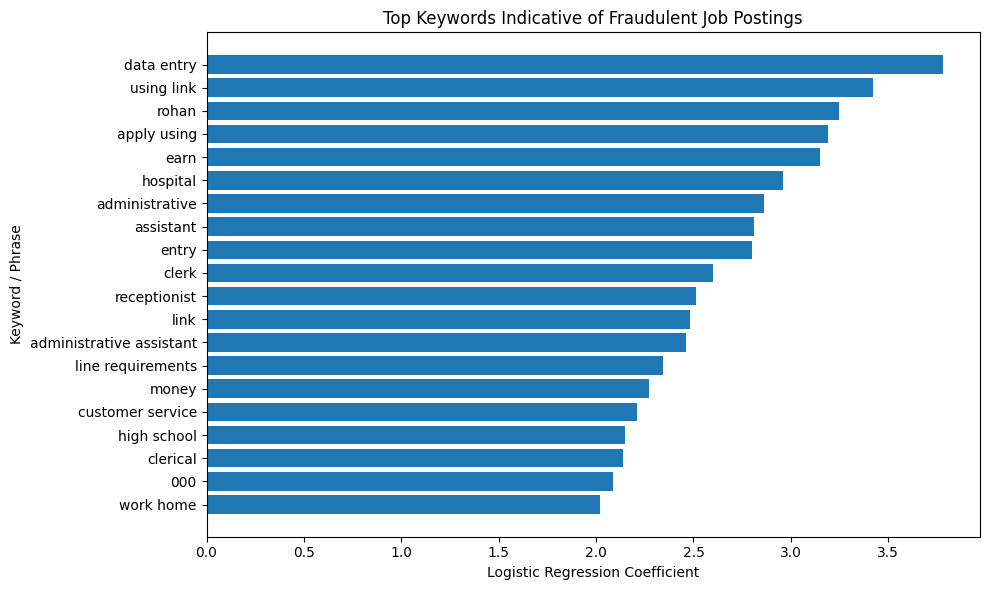

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    top_fraud_words["keyword"],
    top_fraud_words["weight"]
)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Keyword / Phrase")
plt.title("Top Keywords Indicative of Fraudulent Job Postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


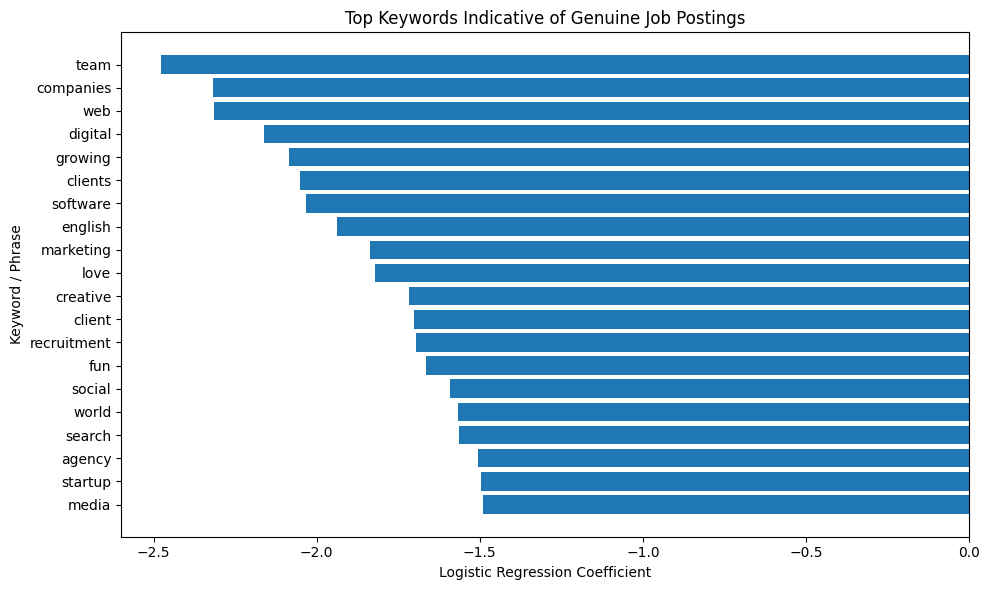

In [ ]:
top_real_words = coef_df.sort_values(by="weight").head(20)

plt.figure(figsize=(10, 6))
plt.barh(
    top_real_words["keyword"],
    top_real_words["weight"]
)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Keyword / Phrase")
plt.title("Top Keywords Indicative of Genuine Job Postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
